<a href="https://colab.research.google.com/github/antonyza/multimodal-music-analysis/blob/main/part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dependencies

In [1]:
!pip install sentence-transformers

# 1. Data Collection

## Data filtering
Keep the songs belonging to 5 genres only.

Those genres are personally picked.

In [2]:
import pandas as pd

url = 'https://raw.githubusercontent.com/antonyza/multimodal-music-analysis/refs/heads/main/Data/id_genres.csv'
my_genres = ['techno', 'country', 'emo', 'reggae', 'jazz']
chunk_size = 500
filtered_id_genres = []

for chunk in pd.read_csv(url, sep='\t', chunksize=chunk_size):
    chunk = chunk.dropna(subset=['genres']).copy() # Remove empty lines
    chunk['genres'] = chunk['genres'].str.split(',') # Split genres column (strings) into a list of genres
    chunk = chunk.explode('genres') # Explode the list of genres into separate rows (same song ID)
    chunk = chunk[chunk['genres'].isin(my_genres)].rename(columns={"genres": "genre"}) # Filter the genres

    if not chunk.empty:
        filtered_id_genres.append(chunk)

df_genre = pd.concat(filtered_id_genres, ignore_index=True)
df_genre = df_genre.groupby('id')['genre'].apply(
    lambda x: list(x.unique()) if len(x.unique()) > 1 else x.iloc[0] # remove duplicates
).reset_index()

df_genre.head(5)

,id,genre
0,00KSCJkYb8JKa4Y3,emo
1,0130k7BE0WlWUQLg,emo
2,02RGE9FNH65RtMS7,techno
3,02S1suSkE5dLFuQh,techno
4,02cqDSNdfTyOD1AI,country


Filter the other CSV file data based on the song IDs we kept

In [3]:
valid_ids = set(df_genre['id'])

# ID-Information
url = 'https://raw.githubusercontent.com/antonyza/multimodal-music-analysis/refs/heads/main/Data/id_information.csv'
filtered_id_info = []

for chunk in pd.read_csv(url, sep='\t', chunksize=chunk_size):
    chunk = chunk[chunk['id'].isin(valid_ids)] # keep from valid song IDs
    if not chunk.empty:
        filtered_id_info.append(chunk)

df_id_info = pd.concat(filtered_id_info, ignore_index=True)


# ID-Tags
url = 'https://raw.githubusercontent.com/antonyza/multimodal-music-analysis/refs/heads/main/Data/id_tags.csv'
filtered_id_tags = []

for chunk in pd.read_csv(url, sep='\t', chunksize=chunk_size):
    chunk = chunk[chunk['id'].isin(valid_ids)] # keep from valid song IDs

    if not chunk.empty:
        filtered_id_tags.append(chunk)

df_id_tags = pd.concat(filtered_id_tags, ignore_index=True)

Get lyrics from filtered IDs

In [4]:
from os.path import isfile
import tarfile
import urllib.request

# Lyrics
url = 'https://raw.githubusercontent.com/antonyza/multimodal-music-analysis/main/Data/processed_lyrics.tar.gz'
tar_path = 'processed_lyrics.tar.gz'
urllib.request.urlretrieve(url, tar_path)
lyrics = []

with tarfile.open(tar_path, 'r:gz') as tar:
    for member in tar.getmembers():
        if member.isfile:
            file_id = member.name.split('/')[-1].split('.')[0] # Get ID from file name (remove .txt)

            if file_id in valid_ids:
                file = tar.extractfile(member)
                if file is not None:
                    content = file.read().decode('utf-8')
                    if not content.strip(): # if empty file (no lyrics) then its instrumental
                        content = 'instrumental'

                    lyrics.append({'id': file_id, 'lyrics': content})

df_lyrics = pd.DataFrame(lyrics)
df_lyrics.head()

,id,lyrics
0,YWEVpqA38ezG0dPU,citi shoe clueless blue pay view noman news bl...
1,wzU0Ts9ZAMfwPqAl,get crush sweeti pie day nighttim hear sigh ne...
2,aB5MGbb1KGWRgl2N,tear open packag empti box mean empti box send...
3,M43AP50YsKZVwzbc,could ever let go go beg drive mad say someth ...
4,9Y3mWcWntTVnpXXh,levit round go stop know float away bend break...


Get MFCC stats

In [5]:
url = 'https://raw.githubusercontent.com/antonyza/multimodal-music-analysis/main/Data/id_mfcc_stats.tsv.bz2'
filtered_mfcc_stats = []

for chunk in pd.read_csv(url, sep='\t', chunksize=chunk_size):
    chunk = chunk[chunk['id'].isin(valid_ids)] # keep from valid song IDs

    if not chunk.empty:
        filtered_mfcc_stats.append(chunk)

df_mfcc_stats = pd.concat(filtered_mfcc_stats, ignore_index=True)
df_mfcc_stats.head()

,id,MFCC000,MFCC001,MFCC002,MFCC003,MFCC004,MFCC005,MFCC006,MFCC007,MFCC008,...,cov_9_9,cov_9_10,cov_9_11,cov_9_12,cov_10_10,cov_10_11,cov_10_12,cov_11_11,cov_11_12,cov_12_12
0,rLfjv8ackxbMBhNm,19.673954,7.374847,-15.109837,-11.847433,0.264044,-18.521660,-7.466475,-2.242330,-13.572355,...,118.288409,5.729727,-4.038114,-14.874527,114.725826,18.788491,-3.406951,97.033048,19.932110,91.360570
1,RLHbq9UXd6cof8Hs,24.639158,-12.822001,-7.392960,-6.209181,-2.153774,-2.274888,-3.867082,-1.193819,-1.405178,...,119.159003,54.040871,33.615619,22.343001,71.530292,38.250632,21.195860,84.002375,47.080897,77.398648
2,j1dQ6TZ3bXn6Ynyt,24.088564,-4.647918,-7.447447,2.401356,-10.061542,1.907399,-5.167847,3.960707,0.971683,...,89.620570,13.797518,8.197030,-7.193006,103.671687,10.435869,-0.186379,83.345863,1.543711,79.169231
3,lRAC2JboOOofsTuE,23.276661,-8.367137,-6.481616,-3.801927,-8.432757,-0.617347,-3.797227,2.791821,1.650162,...,116.750916,29.797668,2.512981,16.170507,103.003531,36.900034,11.820328,87.713964,27.236822,82.561620
4,lrbEv0Tu2jLNlMmD,23.848660,-17.799595,-11.282082,1.395223,-4.768649,1.460606,-0.365338,12.974216,1.694667,...,86.538263,33.140836,5.496330,-0.937074,94.077416,35.472765,-6.621396,72.174649,22.249008,77.636431


Merge and clean the above dataframes into one

In [6]:
# Merge
temp = pd.merge(df_genre, df_lyrics, on='id', how='inner')
df_merged = pd.merge(temp, df_mfcc_stats, on='id', how='inner')


# Clean
mfcc_cols = [col for col in df_merged.columns if col not in ['id', 'genre', 'lyrics']] # Get all MFCC columns
df_merged['mfcc_stats'] = df_merged[mfcc_cols].values.tolist() # Merge MFCC columns into one column (list)
df_merged = df_merged[['id', 'genre', 'lyrics', 'mfcc_stats']] # keep those 4 columns now

print('Data collection complete with final dataframe shape', df_merged.shape)
df_merged.head(20)

Data collection complete with final dataframe shape (7900, 4)


,id,genre,lyrics,mfcc_stats
0,00KSCJkYb8JKa4Y3,emo,fuck nobodi anybodi somebodi nobodi anybodi on...,"[24.40309333801269, -16.733760833740234, -8.50..."
1,0130k7BE0WlWUQLg,emo,tire wake tire well trite say tri chang leg ac...,"[23.711875915527344, -12.89763641357422, -5.54..."
2,02RGE9FNH65RtMS7,techno,fame hold vain letter play game hard love get ...,"[21.82469749450684, -18.16270637512207, -3.055..."
3,02S1suSkE5dLFuQh,techno,instrumental,"[23.05133056640625, -8.015624046325684, -28.29..."
4,02cqDSNdfTyOD1AI,country,hope day come easi moment pass slow road lead ...,"[24.18877601623535, -10.060083389282228, -10.9..."
5,03PbpZwYbPjAUBqB,jazz,go run go run go run go run oh sinn man go run...,"[23.98193550109864, -3.5930917263031006, -5.61..."
6,03dA0mAJj48nT2ab,jazz,tire day get home strang unfamiliar feel kind ...,"[23.773550033569336, -4.35776948928833, 0.2221..."
7,04KIChLwxgxSGbkD,jazz,instrumental,"[21.67498588562012, -3.3346436023712163, -5.62..."
8,04La8lPgQyShB5dr,jazz,want slave want work day want true want make l...,"[21.761722564697266, -16.000164031982422, -12...."
9,04SlsdFaQIDnfvr9,jazz,instrumental,"[23.14767074584961, -17.720975875854492, 2.716..."


## Check for any null/nan values in the final dataframe

In [7]:
import numpy as np

print('--- Null/NaN Values per column ---')
print(df_merged.isna().sum())

# empty strings in lyrics column
empty_lyrics = df_merged[df_merged['lyrics'].str.strip() == ''].shape[0]
print(f'\nSongs with empty lyric strings: {empty_lyrics}')

# empty mfcc stats lists
empty_mfcc = df_merged[df_merged['mfcc_stats'].apply(lambda x: len(x) == 0 if isinstance(x, list) else True)].shape[0]
print(f'\nSongs with empty MFCC lists: {empty_mfcc}')

# ensure mfcc list is the same length for every song
unique_lengths = df_merged['mfcc_stats'].apply(len).unique()
print(f'Unique list lengths in MFCC lists: {unique_lengths}')

# and also that there are no nan values inside
df_merged['mfcc_nan_count'] = df_merged['mfcc_stats'].apply(lambda x: sum(np.isnan(val) for val in x))
songs_with_nans = df_merged[df_merged['mfcc_nan_count'] > 0].shape[0]
print(f'Songs with NaN values in MFCC lists: {songs_with_nans}')
df_merged = df_merged.drop(columns=['mfcc_nan_count'])

--- Null/NaN Values per column ---
id            0
genre         0
lyrics        0
mfcc_stats    0
dtype: int64

Songs with empty lyric strings: 0

Songs with empty MFCC lists: 0
Unique list lengths in MFCC lists: [104]
Songs with NaN values in MFCC lists: 0


## Also check for any HTML elements

In [8]:
import re

has_html = df_merged['lyrics'].str.contains(r'<[^>]+>', regex=True, na=False)
html_count = has_html.sum()

print(f"Songs with HTML tags: {html_count}")

Songs with HTML tags: 0


# 2. Feature extraction

## Text embeddings

We opted for a pre-trained BERT-based sentence transformer from HuggingFace (stsb-bert-base) since, in contrast to Word2vec, its contextual and can handle vocalizations (e.g. "la la la" etc...), which are common in songs, thus, providing a better, overall, semantic analysis.

In [9]:
from sentence_transformers import SentenceTransformer

# load pre-trained bert-based sentence transformer
model = SentenceTransformer('stsb-bert-base')

# create the embeddings from the lyrics directly
lyrics_list = df_merged['lyrics'].tolist()
bert_embeddings = model.encode(lyrics_list, show_progress_bar=True)

# save to dataframe
df_merged['text_embedding'] = bert_embeddings.tolist()

print(f"BERT Embeddings created with shape: {bert_embeddings.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/247 [00:00<?, ?it/s]

BERT Embeddings created with shape: (7900, 768)


## Audio Embeddings

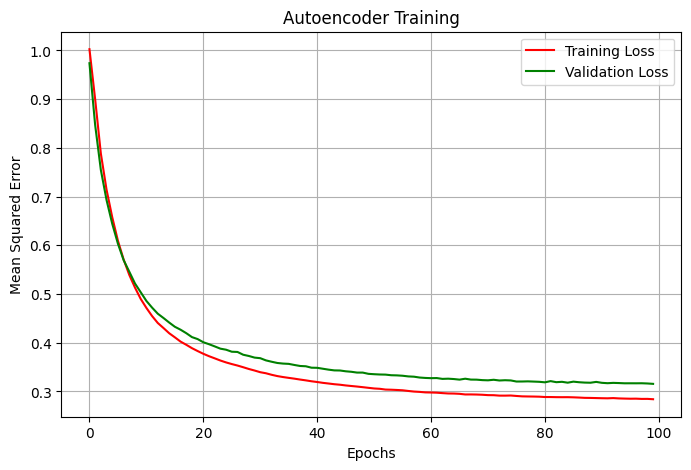

247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Final validation loss: 0.32
Auto-encoder embeddings created with shape: (7900,)


In [20]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


# scale the mfcc stats first for the neural network
mfccArray = np.array(df_merged['mfcc_stats'].tolist())
scaler = StandardScaler()
mfccArray = scaler.fit_transform(mfccArray)

input_dim = mfccArray.shape[1] # mfcc list size
encoding_dim = 32  # bottleneck layer = 32



# input (input_dim size)
input_layer = Input(shape=(input_dim,))

# encode (input_dim->64->32 neurons)
encoded = Dense(64, activation='relu')(input_layer)
bottleneck = Dense(encoding_dim, activation='relu')(encoded)

# decode (32-64->input_dim neurons)
decoded = Dense(64, activation='relu')(bottleneck)
output_layer = Dense(input_dim, activation='linear')(decoded)

# make model
autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# train the model
# use early stopping mechanism to stop training when validation loss stops getting better
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = autoencoder.fit(
    mfccArray, mfccArray,
    epochs=100,
    batch_size=256,
    shuffle=True,
    callbacks=[early_stop],
    validation_split=0.2, # avoid overfitting
    verbose=0
)

# plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='green')
plt.title('Autoencoder Training')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

# get the model that gives just the bottleneck layer
encoder = Model(inputs=input_layer, outputs=bottleneck)

# extract audio embeddings as a 32-dimension vectors
audio_embeddings = encoder.predict(mfccArray)

# save
df_merged['audio_embedding'] = audio_embeddings.tolist()

print(f'Final validation loss: {min(history.history['val_loss']):.2f}')
print(f'Auto-encoder embeddings created with shape: {df_merged['audio_embedding'].shape}')